In [3]:
#loading the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('superstore.csv', encoding='cp1252')
df.head()




,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


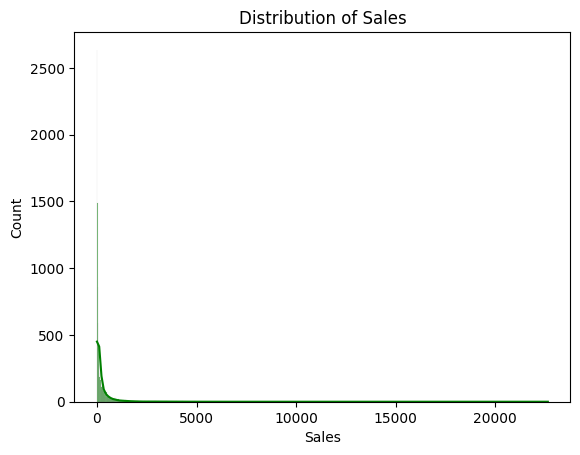

mean 229.85800083049833
median 54.489999999999995


In [8]:
#task 1
sns.histplot(df['Sales'],kde=True,color='green')
plt.title('Distribution of Sales')
plt.show()
print("mean", np.mean(df['Sales']))
print("median", np.median(df['Sales']))

#it is right skewed and the number of outiers is greater

/tmp/ipykernel_1443/2443029630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x='Category',y='Profit',palette='muted',legend='False')


<Axes: xlabel='Category', ylabel='Profit'>

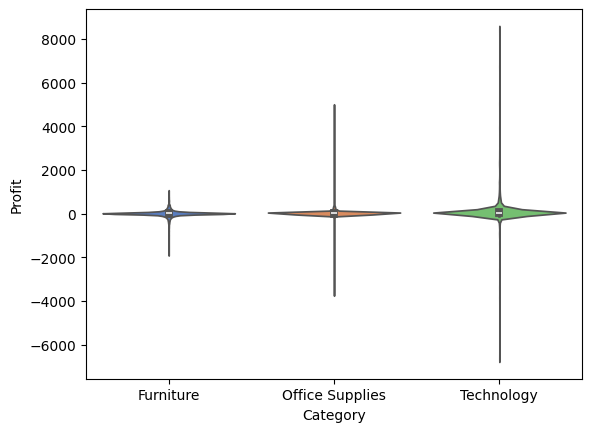

In [14]:
#task 2
sns.violinplot(data=df,x='Category',y='Profit',palette='muted',legend='False')

The violin plot better reveals a bimodal or unusually spread-out distribution because its shape shows the density and multiple peaks of the data. The strip plot shows individual observations clearly, but overlapping points can make distribution patterns harder to see.


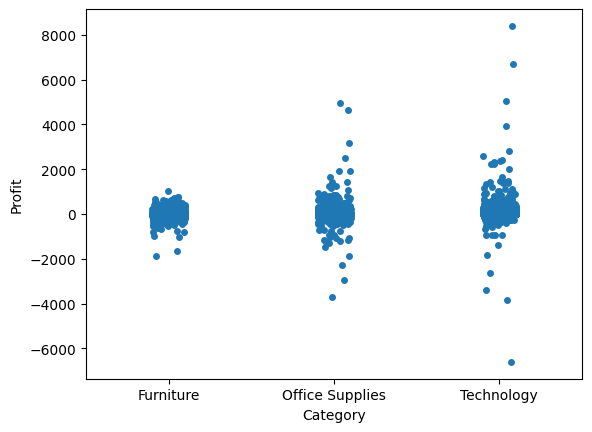

In [16]:
sns.stripplot(data=df,x='Category',y='Profit')
print("The violin plot better reveals a bimodal or unusually spread-out distribution because its shape shows the density and multiple peaks of the data. The strip plot shows individual observations clearly, but overlapping points can make distribution patterns harder to see.")

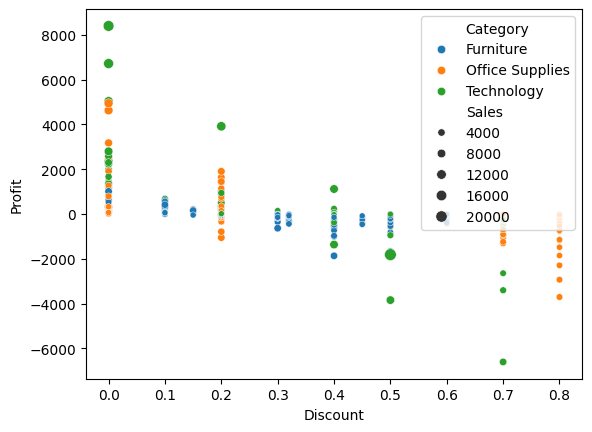

In [21]:
#task 3
sns.scatterplot(data=df,x='Discount',y='Profit',hue='Category',size='Sales')
plt.legend(loc='upper right')
plt.show(" some of the largest-sales transactions (larger bubbles) are associated with very large losses at higher discounts, particularly in Technology.")

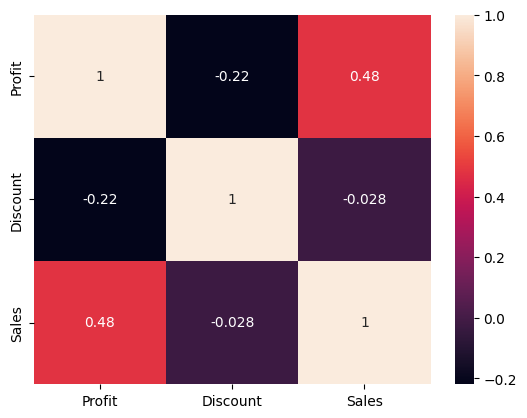

In [26]:
#task 4
nums=['Profit','Discount','Sales']
pearson_matrix=df[nums].corr(method='pearson')
sns.heatmap(pearson_matrix,annot=True)
plt.show()

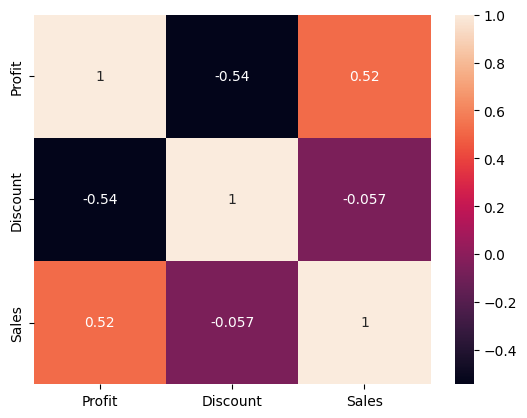

In [28]:
spearman_matrix=df[nums].corr(method='spearman')
sns.heatmap(spearman_matrix,annot=True)
plt.show()

 The scatter plot suggests that the difference is caused by [outliers/non-linearity]; Pearson is more sensitive to extreme values and measures linear association, whereas Spearman measures the strength of the rank-order relationship. Correlation does not imply causation, so even a strong correlation between two variables does not establish that one causes the other.

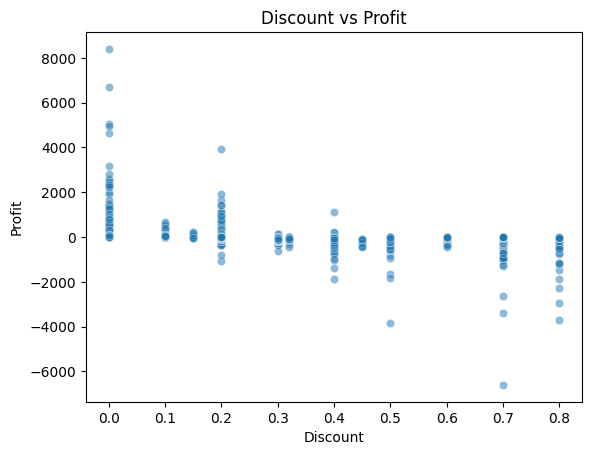

In [31]:
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.title("Discount vs Profit")
plt.show()


Category    Furniture  Office Supplies  Technology           All
Region                                                          
Central   163797.1638       167026.415  170416.312  5.012399e+05
East      208291.2040       205516.055  264973.981  6.787812e+05
South     117298.6840       125651.313  148771.908  3.917219e+05
West      252612.7435       220853.249  251991.832  7.254578e+05
All       741999.7953       719047.032  836154.033  2.297201e+06


<Axes: xlabel='Category', ylabel='Region'>

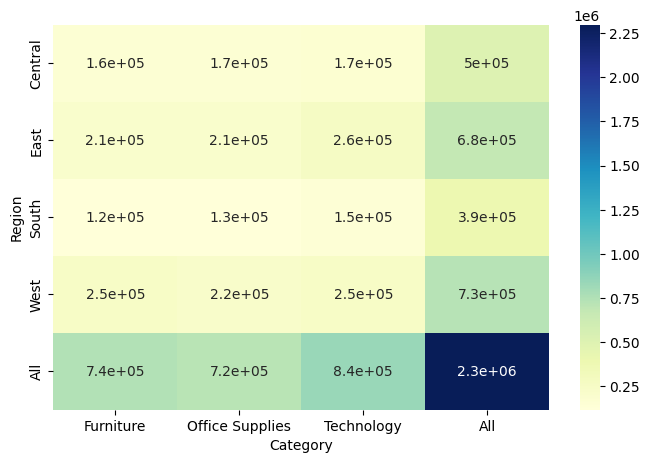

In [46]:
#task 5
sales_pivot=pd.pivot_table(data=df,values='Sales',index='Region',columns='Category',aggfunc='sum',margins=True)
print(sales_pivot)
plt.figure(figsize=(8, 5))
sns.heatmap(sales_pivot,annot=True,cmap='YlGnBu')
#sales in east and category technology is the greatest


It highlights sustained increases or decreases while reducing the visual impact of unusually high or low individual months.


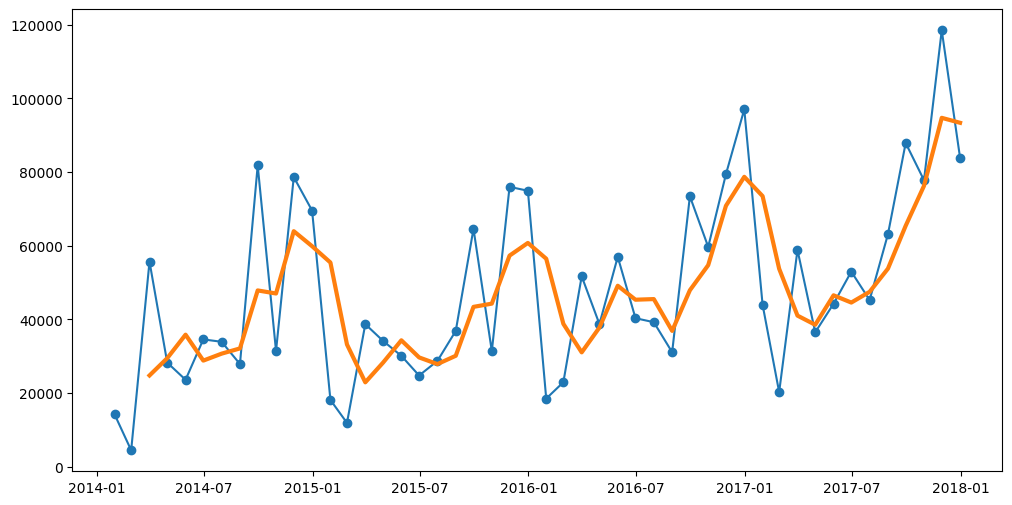

In [50]:
#task 6
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.set_index('Order Date')['Sales'].resample('ME').sum()
rolling_3m = monthly_sales.rolling(window=3).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales, label='Monthly Sales', marker='o')
plt.plot(rolling_3m.index, rolling_3m, label='3-Month Rolling Average',linewidth=3)

print("It highlights sustained increases or decreases while reducing the visual impact of unusually high or low individual months.")

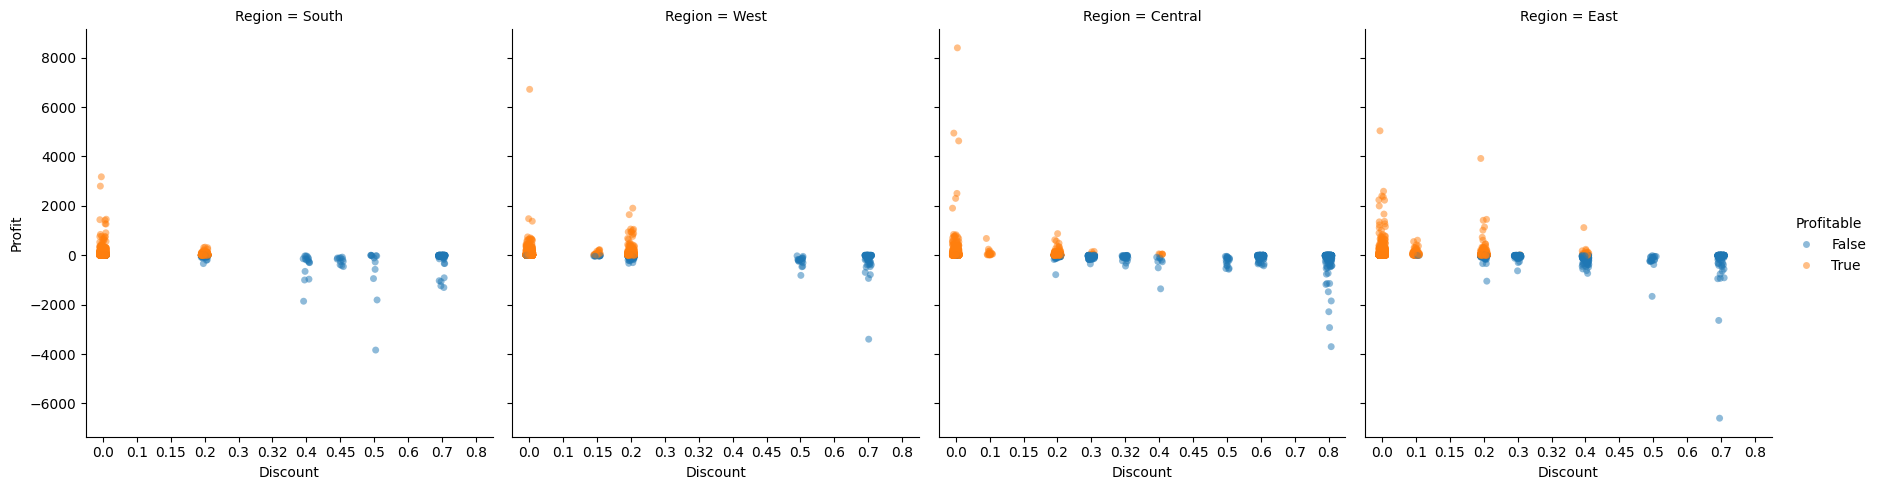

The Central region visibly differs from the others, with a stronger concentration of negative-profit orders as discount increases. This suggests that higher discounts are more consistently associated with losses in the Central region than in some of the other regions.


In [56]:
df['Profitable'] = df['Profit'] > 0

sns.catplot(data=df,x='Discount',y='Profit',col='Region',hue='Profitable',kind='strip',height=5,aspect=0.9,alpha=0.5,jitter=True)

plt.show()
print("The Central region visibly differs from the others, with a stronger concentration of negative-profit orders as discount increases. This suggests that higher discounts are more consistently associated with losses in the Central region than in some of the other regions.")

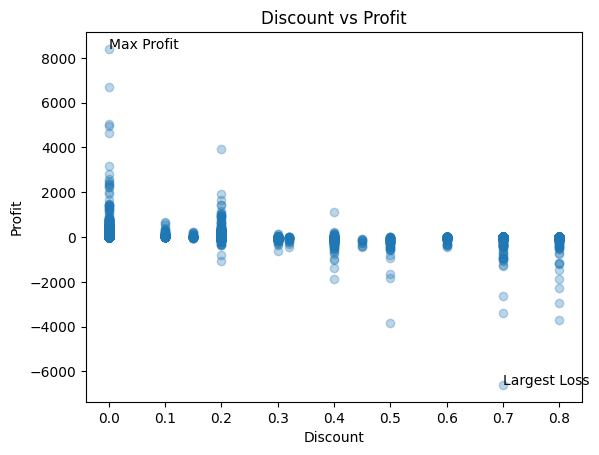

In [57]:
#task 8
plt.scatter(df['Discount'], df['Profit'], alpha=0.3)

# Most profitable and biggest loss
max_profit = df.loc[df['Profit'].idxmax()]
max_loss = df.loc[df['Profit'].idxmin()]

plt.annotate('Max Profit',
             (max_profit['Discount'], max_profit['Profit']))

plt.annotate('Largest Loss',
             (max_loss['Discount'], max_loss['Profit']))

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()